In [1]:
### LIBRARIES ###
library(Seurat)
library(ggridges)
library(H5weaver)
library(Matrix)
library(ggplot2)
library(magrittr)
library(data.table)
library(dplyr)
library(ggplot2)
library(SingleCellExperiment)
library(DESeq2)

Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built with package ‘Matrix’ 1.7.2 but the current
version is 1.7.3; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: data.table

Warning message:
“package ‘data.table’ was built under R version 4.4.3”
Loading required package: Matrix

Warning message:
“package ‘Matrix’ was built under R version 4.4.3”
Loading required package: rhdf5

Warning message:
“package ‘rhdf5’ was built under R version 4.4.3”

Attaching package: ‘H5weaver’


The following objects are masked from ‘package:rhdf5’:

    h5dump, h5ls


Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked

In [2]:
prime5 <- readRDS('so_clean.rds')
prime3 <- readRDS('prime3_iso_subset.rds')

# Align metadata columns for plotting prior to merge

## Align 5' data

In [3]:
table(prime5$igh_c_gene)


IGHA1 IGHA2  IGHD  IGHE IGHG1 IGHG2 IGHG3 IGHG4  IGHM IGLC1    NA 
 6548  1156  1927     2  3889  1885   929    63 87885     1  4092 

In [4]:
prime5_clean <- subset(prime5, igh_c_gene %in% c('IGLC1','NA'), invert = TRUE)
table(prime5_clean$igh_c_gene)


IGHA1 IGHA2  IGHD  IGHE IGHG1 IGHG2 IGHG3 IGHG4  IGHM 
 6548  1156  1927     2  3889  1885   929    63 87885 

In [5]:
unswitched_genes <- c('IGHM','IGHMD','IGHD')
switched_genes <- c('IGHG3','IGHG1','IGHA1','IGHG2','IGHG4','IGHE','IGHA2')

In [6]:
prime5_clean$switched_status <- prime5_clean$igh_c_gene

In [7]:
prime5_clean$switched_status[prime5_clean$igh_c_gene %in% unswitched_genes] <- 'nonswitched'
prime5_clean$switched_status[prime5_clean$igh_c_gene %in% switched_genes] <- 'switched'
table(prime5_clean$switched_status)


nonswitched    switched 
      89812       14472 

In [8]:
prime5_clean$tech <- 'prime5'

In [9]:
table(prime5_clean$pbmc_sample_id)


SP00257-01-1 SP00257-01-2 SP00287-02-1 SP00287-02-2 SP01565-01-1 SP01565-01-2 
       16269        15930        12798        10955        11691        10903 
SP01606-01-1 SP01606-01-2 
       14853        10885 

In [10]:
prime5_clean <- SetIdent(prime5_clean, value = 'pbmc_sample_id')
prime5_clean <- RenameIdents(prime5_clean,
                             'SP00257-01-1' = 'PB00257-01',
                             'SP00257-01-2' = 'PB00257-01',
                             'SP00287-02-1' = 'PB00287-01',
                             'SP00287-02-2' = 'PB00287-01',
                             'SP01565-01-1' = 'PB01565-01',
                             'SP01565-01-2' = 'PB01565-01',
                             'SP01606-01-1' = 'PB01606-01',
                             'SP01606-01-2' = 'PB01606-01')
prime5_clean$pbmc_sample_id_align <- Idents(prime5_clean)

## Align 3' data

In [11]:
table(prime3$pbmc_sample_id)


PB00257-01 PB00287-01 PB01565-01 PB01606-01 
      1484       1523       1335       1528 

In [12]:
prime3$pbmc_sample_id_align <- prime3$pbmc_sample_id

In [13]:
table(prime3$switched_status)


 nonswitched     switched undetermined 
        5181          667           22 

In [14]:
prime3_clean <- subset(prime3, isotype == 'undetermined', invert = TRUE)
table(prime3_clean$isotype)


    IGHA1     IGHA2      IGHD     IGHG1     IGHG2     IGHG3     IGHG4      IGHM 
      247         8        22       162        41       196        13       869 
IGHM;IGHD 
     4290 

In [15]:
prime3_clean$tech <- 'prime3'

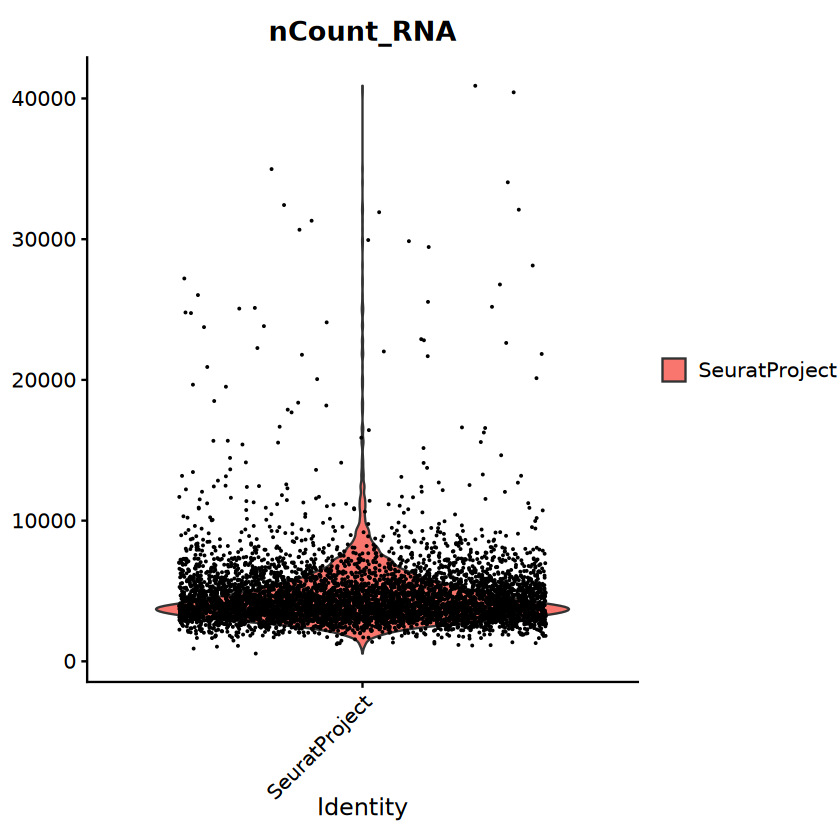

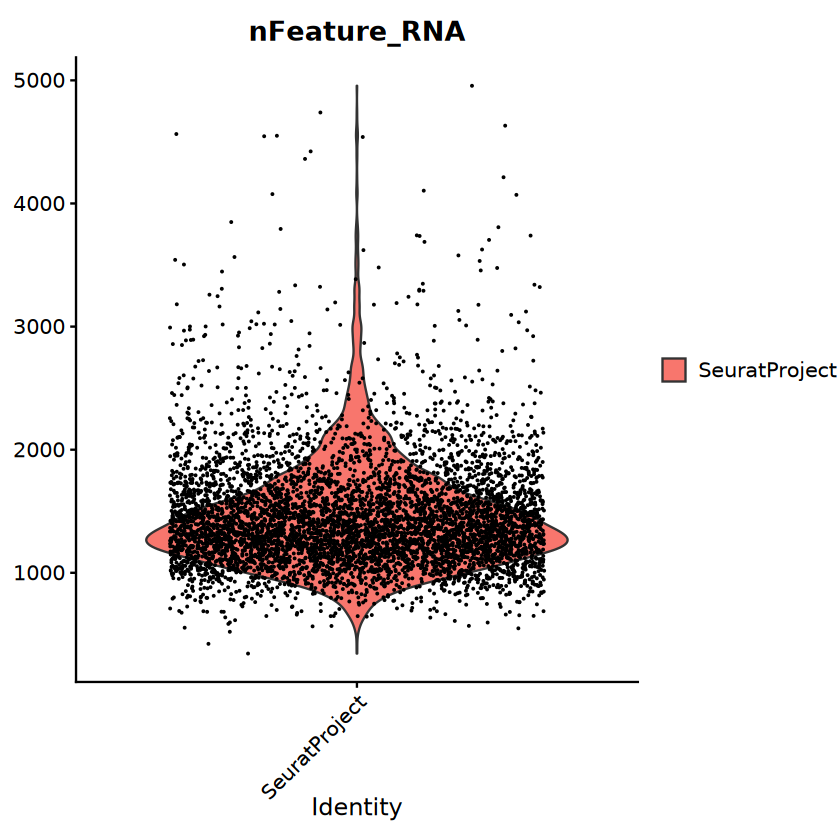

In [16]:
VlnPlot(prime3_clean, features = 'nCount_RNA')
VlnPlot(prime3_clean, features = 'nFeature_RNA')

In [17]:
prime3_clean <- subset(prime3_clean, nCount_RNA < 20000)

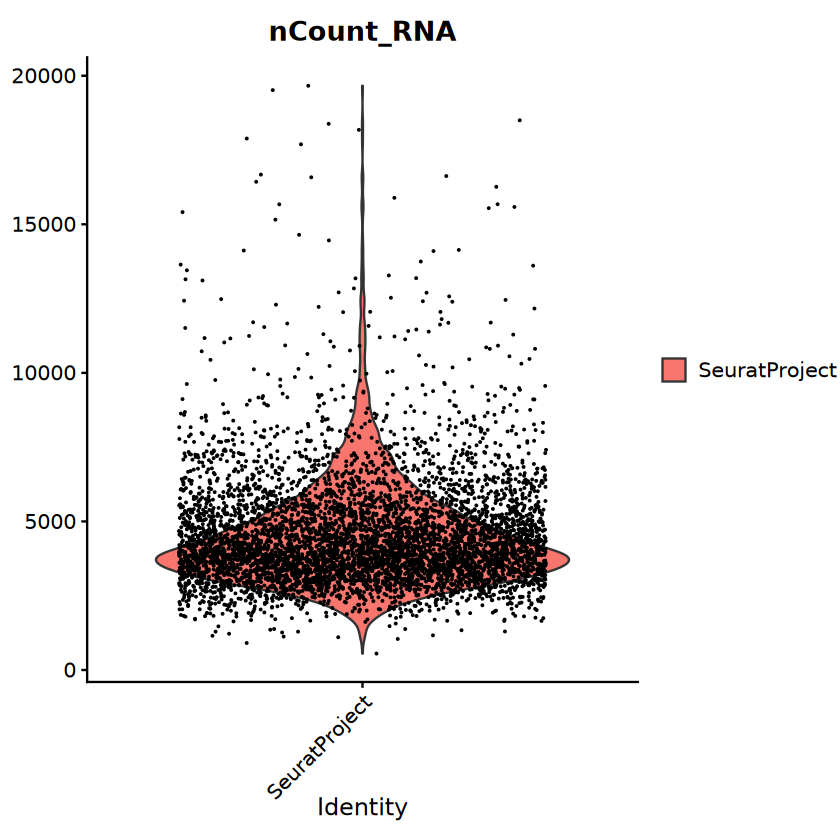

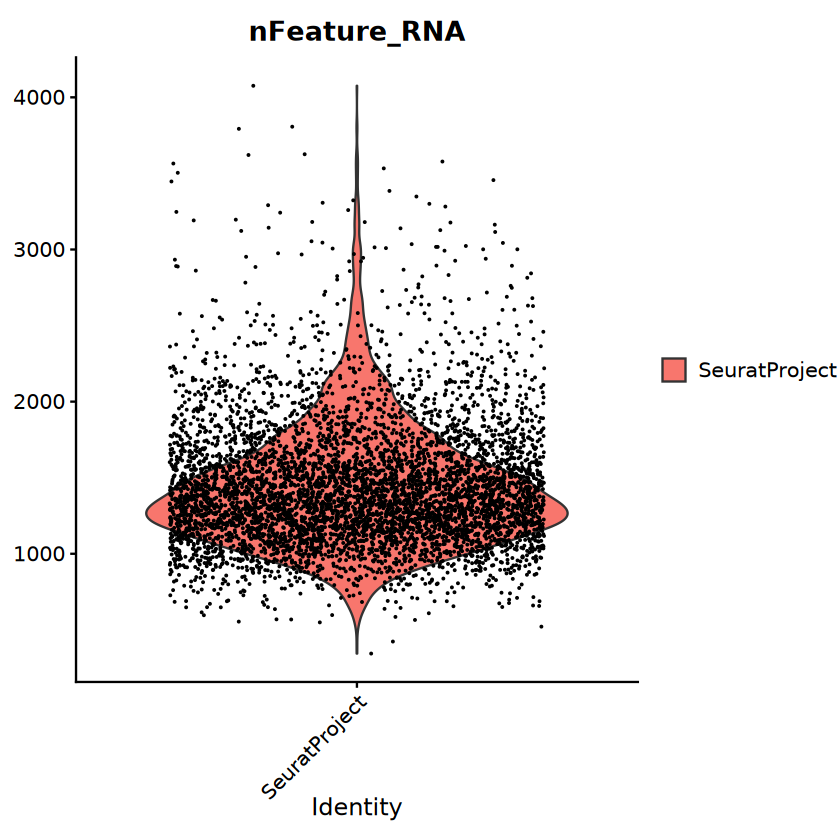

In [18]:
VlnPlot(prime3_clean, features = 'nCount_RNA')
VlnPlot(prime3_clean, features = 'nFeature_RNA')

## Merge

In [19]:
merged_obj <- merge(x = prime5_clean, y = prime3_clean)

In [20]:
merged_obj

An object of class Seurat 
38264 features across 110096 samples within 2 assays 
Active assay: RNA (38224 features, 2000 variable features)
 5 layers present: counts.1, counts.2, data.1, scale.data.1, data.2
 1 other assay present: ADT

In [21]:
merged_obj[["RNA"]] <- JoinLayers(merged_obj[['RNA']])
merged_obj <- NormalizeData(merged_obj) %>% FindVariableFeatures() %>% ScaleData()

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Warning message:
“Different features in new layer data than already exists for scale.data”
Warning message:
“Different cells in new layer data than already exists for scale.data”


In [22]:
merged_obj

An object of class Seurat 
38264 features across 110096 samples within 2 assays 
Active assay: RNA (38224 features, 2000 variable features)
 4 layers present: data, counts, scale.data.1, scale.data
 1 other assay present: ADT

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



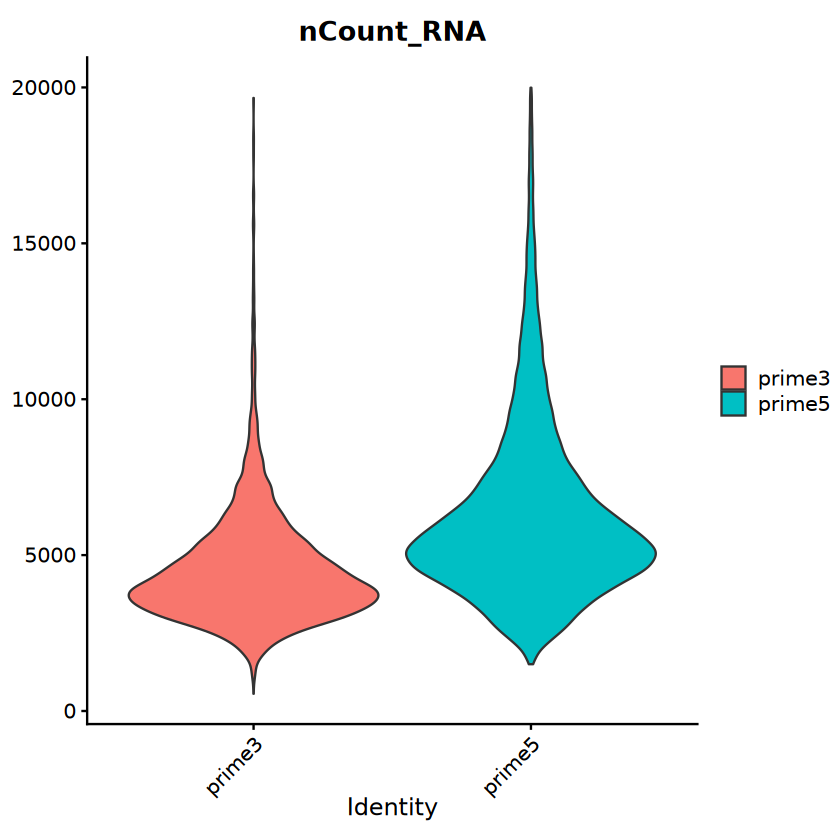

In [23]:
VlnPlot(merged_obj, features = 'nCount_RNA', group.by = 'tech', pt.size = 0)

## Subset nonswitched B cells

In [24]:
non_switch <- subset(merged_obj, switched_status == 'nonswitched')

### Get Pseudobulk & VST

In [25]:
bulk_non_switch <- AggregateExpression(non_switch, assays = 'RNA', group.by = c('pbmc_sample_id_align','tech'), return.seurat = 'TRUE')

Centering and scaling data matrix



In [26]:
bulk_non_switch

An object of class Seurat 
38224 features across 8 samples within 1 assay 
Active assay: RNA (38224 features, 0 variable features)
 3 layers present: counts, data, scale.data

In [27]:
head(bulk_non_switch[['RNA']]$counts)

6 x 8 sparse Matrix of class "dgCMatrix"
            PB00257-01_prime3 PB00257-01_prime5 PB00287-01_prime3
MIR1302-2HG                 .                 2                 .
FAM138A                     .                 .                 .
OR4F5                       .                 .                 .
AL627309.1                  4                49                 2
AL627309.3                  .                 2                 1
AL627309.2                  .                 .                 .
            PB00287-01_prime5 PB01565-01_prime3 PB01565-01_prime5
MIR1302-2HG                 .                 .                 1
FAM138A                     .                 .                 .
OR4F5                       .                 .                 .
AL627309.1                 46                 .                31
AL627309.3                  1                 .                 1
AL627309.2                  .                 .                 .
            PB01606-01_prime3 PB016

In [28]:
dds <- DESeqDataSetFromMatrix(countData = bulk_non_switch[['RNA']]$counts, colData = bulk_non_switch@meta.data, design = ~ pbmc_sample_id_align + tech)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



In [29]:
dds

class: DESeqDataSet 
dim: 38224 8 
metadata(1): version
assays(1): counts
rownames(38224): MIR1302-2HG FAM138A ... AC004556.1 FAM231C
rowData names(0):
colnames(8): PB00257-01_prime3 PB00257-01_prime5 ... PB01606-01_prime3
  PB01606-01_prime5
colData names(3): orig.ident pbmc_sample_id_align tech

In [30]:
norm_dds <- DESeq2::varianceStabilizingTransformation(dds, blind = TRUE)

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



In [31]:
norm_dds

class: DESeqTransform 
dim: 38224 8 
metadata(1): version
assays(1): ''
rownames(38224): MIR1302-2HG FAM138A ... AC004556.1 FAM231C
rowData names(6): baseMean baseVar ... dispGeneIter dispFit
colnames(8): PB00257-01_prime3 PB00257-01_prime5 ... PB01606-01_prime3
  PB01606-01_prime5
colData names(4): orig.ident pbmc_sample_id_align tech sizeFactor

In [32]:
assay(norm_dds)['IGHG3',]

PB00257-01_prime3 PB00257-01_prime5 PB00287-01_prime3 PB00287-01_prime5 
        10.476210         10.257465          9.718466          9.452285 
PB01565-01_prime3 PB01565-01_prime5 PB01606-01_prime3 PB01606-01_prime5 
         9.768342          9.795217         10.623452         10.847658

In [33]:
bulk_non_switch <- AddMetaData(bulk_non_switch, metadata = assay(norm_dds)['IGHG3',], col.name = 'IGHG3_Exp')

In [34]:
bulk_non_switch$IGHG3_Exp

PB00257-01_prime3 PB00257-01_prime5 PB00287-01_prime3 PB00287-01_prime5 
        10.476210         10.257465          9.718466          9.452285 
PB01565-01_prime3 PB01565-01_prime5 PB01606-01_prime3 PB01606-01_prime5 
         9.768342          9.795217         10.623452         10.847658

In [35]:
head(bulk_non_switch)

,orig.ident,pbmc_sample_id_align,tech,IGHG3_Exp
,<chr>,<chr>,<chr>,<dbl>
PB00257-01_prime3,PB00257-01_prime3,PB00257-01,prime3,10.476210
PB00257-01_prime5,PB00257-01_prime5,PB00257-01,prime5,10.257465
PB00287-01_prime3,PB00287-01_prime3,PB00287-01,prime3,9.718466
PB00287-01_prime5,PB00287-01_prime5,PB00287-01,prime5,9.452285
PB01565-01_prime3,PB01565-01_prime3,PB01565-01,prime3,9.768342
PB01565-01_prime5,PB01565-01_prime5,PB01565-01,prime5,9.795217
PB01606-01_prime3,PB01606-01_prime3,PB01606-01,prime3,10.623452
PB01606-01_prime5,PB01606-01_prime5,PB01606-01,prime5,10.847658


In [39]:
write.csv(bulk_non_switch@meta.data, 'bulk_non_switch_datatable.csv')

In [36]:
bulk_non_switch <- SetIdent(bulk_non_switch, value = 'tech')
bulk_non_switch <- RenameIdents(bulk_non_switch,
                             'prime5' = 'BCRseq Isotyping',
                             'prime3' = 'RNA-based Isotyping')
bulk_non_switch$isotyping_method <- Idents(bulk_non_switch)

In [ ]:
options(repr.plot.width = 9, repr.plot.height = 8)
p2 <- ggplot(bulk_non_switch@meta.data, aes(x=isotyping_method, y=IGHG3_Exp)) + 
        geom_boxplot() + #geom_jitter(aes(color=isotyping_method),shape=16, position=position_jitter(0.2), size=10, alpha=0.5) +
        geom_point(aes(color=isotyping_method),shape=16, size=10, alpha=0.5) +
        geom_line(aes(group=pbmc_sample_id_align)) +
        scale_color_manual(values = c('#415a77','#588157')) + ylim(7,10) +
        theme_bw(base_size=20) + xlab('Isotyping Method') + ylab('IGHG3 Expression') +
        theme(axis.line = element_line(colour = "black"),
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank(),
            panel.border = element_blank(),
            panel.background = element_blank())
p2

### Plot

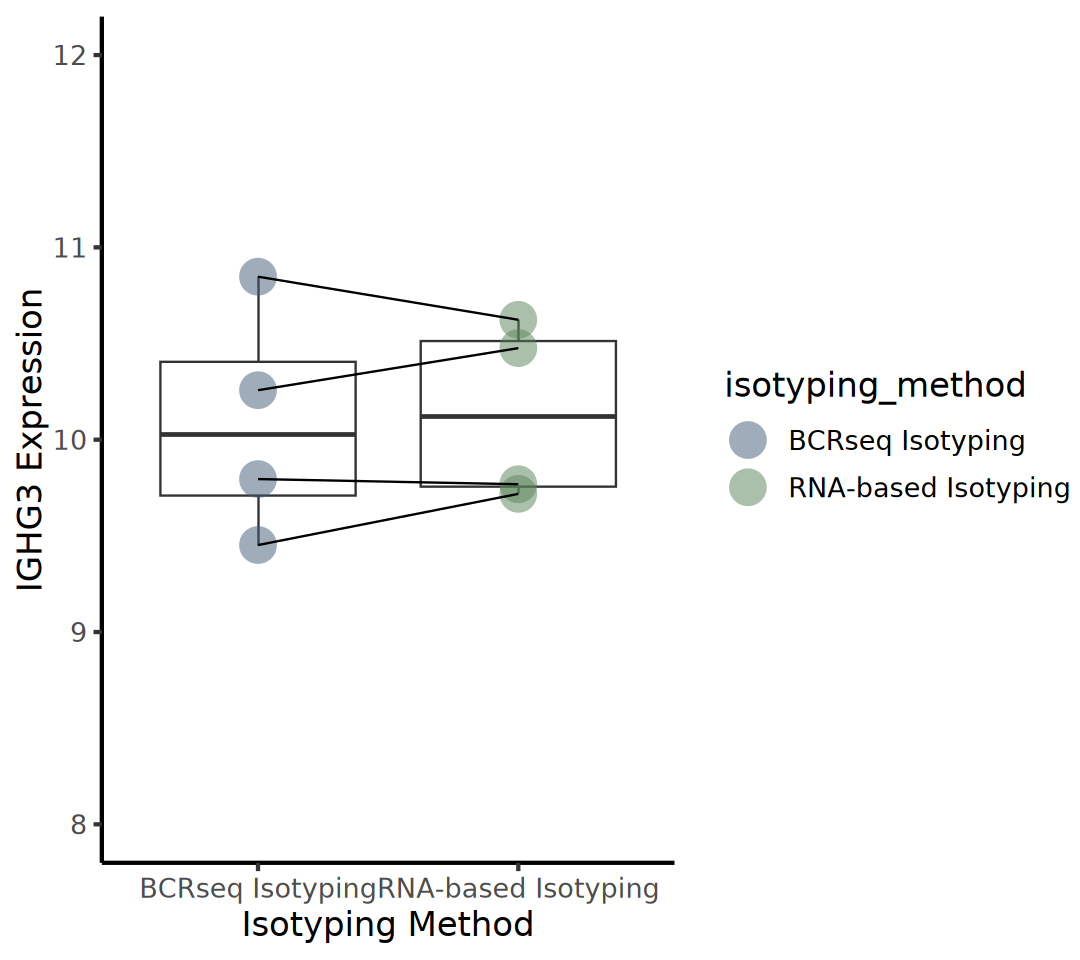

In [37]:
options(repr.plot.width = 9, repr.plot.height = 8)
p <- ggplot(bulk_non_switch@meta.data, aes(x=isotyping_method, y=IGHG3_Exp)) + 
        geom_boxplot() + #geom_jitter(aes(color=isotyping_method),shape=16, position=position_jitter(0.2), size=10, alpha=0.5) +
        geom_point(aes(color=isotyping_method),shape=16, size=10, alpha=0.5) +
        geom_line(aes(group=pbmc_sample_id_align)) +
        ylim(8,12) + scale_color_manual(values = c('#415a77','#588157')) +
        theme_bw(base_size=20) + xlab('Isotyping Method') + ylab('IGHG3 Expression') +
        theme(axis.line = element_line(colour = "black"),
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank(),
            panel.border = element_blank(),
            panel.background = element_blank())
p

In [74]:
# Open a pdf file
pdf("plots/IGHG3_expression_line_update.pdf", width = 9, height = 8) 
# 2. Create a plot
p
# Close the pdf file
dev.off() 

pdf 
  2

## Subset Core Naive nonswitched B cells

In [38]:
table(non_switch$AIFI_PBMC_L3)


       Activated memory B cell          CD27+ effector B cell 
                          1637                           3453 
         CD27- effector B cell             CD95 memory B cell 
                          1547                            850 
            Core memory B cell              Core naive B cell 
                         22987                          60104 
           Early memory B cell              ISG+ naive B cell 
                           417                            940 
                   Plasma cell            Transitional B cell 
                           104                           2593 
Type 2 polarized memory B cell 
                           346 

In [39]:
non_switch_naive <- subset(non_switch, AIFI_PBMC_L3 == 'Core naive B cell')

### Get Pseudobulk & VST

In [40]:
bulk_non_switch_naive <- AggregateExpression(non_switch_naive, assays = 'RNA', group.by = c('pbmc_sample_id_align','tech'), return.seurat = 'TRUE')

Centering and scaling data matrix



In [41]:
bulk_non_switch_naive

An object of class Seurat 
38224 features across 8 samples within 1 assay 
Active assay: RNA (38224 features, 0 variable features)
 3 layers present: counts, data, scale.data

In [42]:
head(bulk_non_switch_naive[['RNA']]$counts)

6 x 8 sparse Matrix of class "dgCMatrix"
            PB00257-01_prime3 PB00257-01_prime5 PB00287-01_prime3
MIR1302-2HG                 .                 2                 .
FAM138A                     .                 .                 .
OR4F5                       .                 .                 .
AL627309.1                  3                32                 1
AL627309.3                  .                 2                 1
AL627309.2                  .                 .                 .
            PB00287-01_prime5 PB01565-01_prime3 PB01565-01_prime5
MIR1302-2HG                 .                 .                 1
FAM138A                     .                 .                 .
OR4F5                       .                 .                 .
AL627309.1                 19                 .                20
AL627309.3                  .                 .                 .
AL627309.2                  .                 .                 .
            PB01606-01_prime3 PB016

In [43]:
dds_naive <- DESeqDataSetFromMatrix(countData = bulk_non_switch_naive[['RNA']]$counts, 
                              colData = bulk_non_switch_naive@meta.data, 
                              design = ~ pbmc_sample_id_align + tech)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



In [44]:
dds_naive

class: DESeqDataSet 
dim: 38224 8 
metadata(1): version
assays(1): counts
rownames(38224): MIR1302-2HG FAM138A ... AC004556.1 FAM231C
rowData names(0):
colnames(8): PB00257-01_prime3 PB00257-01_prime5 ... PB01606-01_prime3
  PB01606-01_prime5
colData names(3): orig.ident pbmc_sample_id_align tech

In [45]:
norm_dds_naive <- DESeq2::varianceStabilizingTransformation(dds_naive, blind = TRUE)

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



In [46]:
norm_dds_naive

class: DESeqTransform 
dim: 38224 8 
metadata(1): version
assays(1): ''
rownames(38224): MIR1302-2HG FAM138A ... AC004556.1 FAM231C
rowData names(6): baseMean baseVar ... dispGeneIter dispFit
colnames(8): PB00257-01_prime3 PB00257-01_prime5 ... PB01606-01_prime3
  PB01606-01_prime5
colData names(4): orig.ident pbmc_sample_id_align tech sizeFactor

In [47]:
assay(norm_dds_naive)['IGHG3',]

PB00257-01_prime3 PB00257-01_prime5 PB00287-01_prime3 PB00287-01_prime5 
         8.880408          9.186738          7.526608          8.895516 
PB01565-01_prime3 PB01565-01_prime5 PB01606-01_prime3 PB01606-01_prime5 
         7.855257          8.864368          8.164874          9.117291

In [48]:
bulk_non_switch_naive <- AddMetaData(bulk_non_switch_naive, metadata = assay(norm_dds_naive)['IGHG3',], col.name = 'IGHG3_Exp')

In [49]:
bulk_non_switch_naive$IGHG3_Exp

PB00257-01_prime3 PB00257-01_prime5 PB00287-01_prime3 PB00287-01_prime5 
         8.880408          9.186738          7.526608          8.895516 
PB01565-01_prime3 PB01565-01_prime5 PB01606-01_prime3 PB01606-01_prime5 
         7.855257          8.864368          8.164874          9.117291

In [50]:
bulk_non_switch_naive <- SetIdent(bulk_non_switch_naive, value = 'tech')
bulk_non_switch_naive <- RenameIdents(bulk_non_switch_naive,
                             'prime5' = 'BCRseq Isotyping',
                             'prime3' = 'RNA-based Isotyping')
bulk_non_switch_naive$isotyping_method <- Idents(bulk_non_switch_naive)

In [55]:
head(bulk_non_switch_naive)

,orig.ident,pbmc_sample_id_align,tech,IGHG3_Exp,isotyping_method
,<chr>,<chr>,<chr>,<dbl>,<fct>
PB00257-01_prime3,PB00257-01_prime3,PB00257-01,prime3,8.880408,RNA-based Isotyping
PB00257-01_prime5,PB00257-01_prime5,PB00257-01,prime5,9.186738,BCRseq Isotyping
PB00287-01_prime3,PB00287-01_prime3,PB00287-01,prime3,7.526608,RNA-based Isotyping
PB00287-01_prime5,PB00287-01_prime5,PB00287-01,prime5,8.895516,BCRseq Isotyping
PB01565-01_prime3,PB01565-01_prime3,PB01565-01,prime3,7.855257,RNA-based Isotyping
PB01565-01_prime5,PB01565-01_prime5,PB01565-01,prime5,8.864368,BCRseq Isotyping
PB01606-01_prime3,PB01606-01_prime3,PB01606-01,prime3,8.164874,RNA-based Isotyping
PB01606-01_prime5,PB01606-01_prime5,PB01606-01,prime5,9.117291,BCRseq Isotyping


### Plot

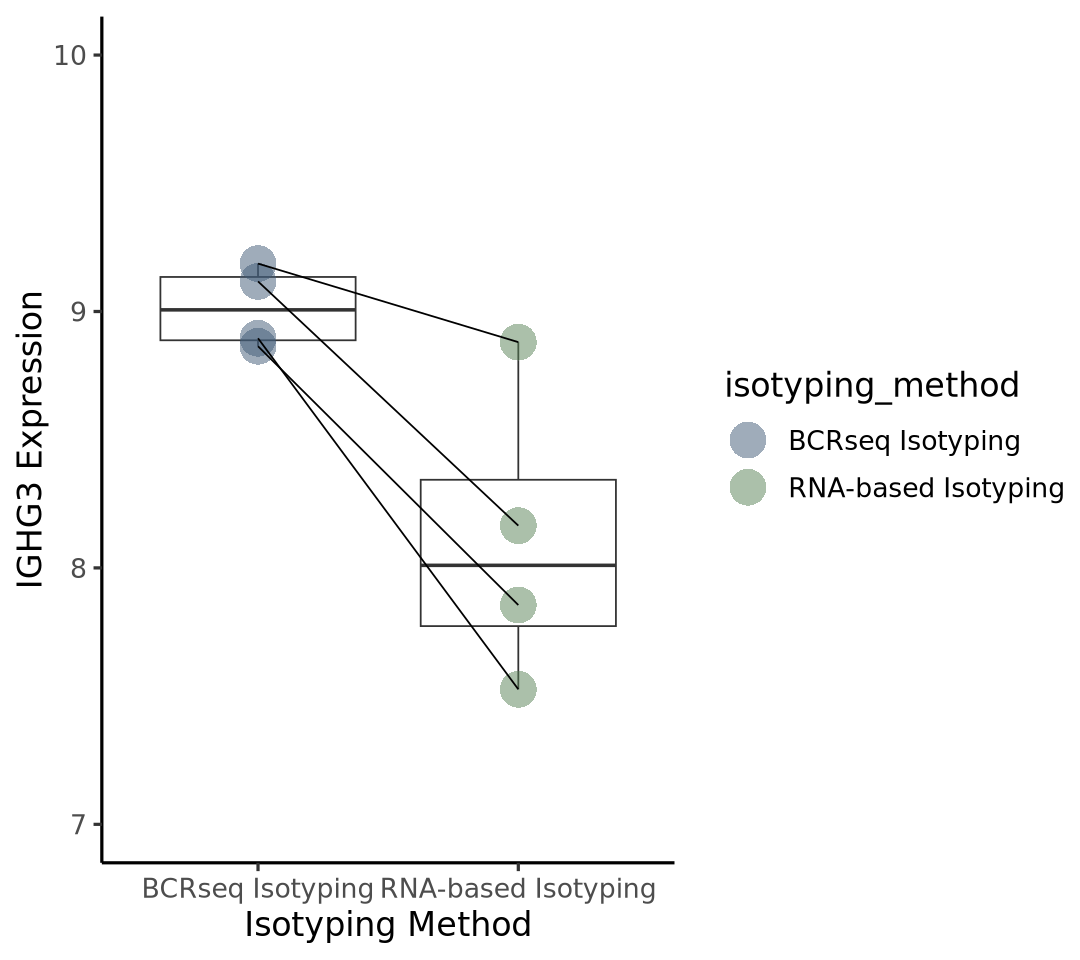

In [70]:
options(repr.plot.width = 9, repr.plot.height = 8)
p2 <- ggplot(bulk_non_switch_naive@meta.data, aes(x=isotyping_method, y=IGHG3_Exp)) + 
        geom_boxplot() + #geom_jitter(aes(color=isotyping_method),shape=16, position=position_jitter(0.2), size=10, alpha=0.5) +
        geom_point(aes(color=isotyping_method),shape=16, size=10, alpha=0.5) +
        geom_line(aes(group=pbmc_sample_id_align)) +
        scale_color_manual(values = c('#415a77','#588157')) + ylim(7,10) +
        theme_bw(base_size=20) + xlab('Isotyping Method') + ylab('IGHG3 Expression') +
        theme(axis.line = element_line(colour = "black"),
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank(),
            panel.border = element_blank(),
            panel.background = element_blank())
p2

In [71]:
# Open a pdf file
pdf("plots/IGHG3_expression_core_naive_line_update.pdf", width = 9, height = 8) 
# 2. Create a plot
p2
# Close the pdf file
dev.off() 

pdf 
  2

# Isotype Proportion Plot

In [53]:
merged_obj$sample_tech <- paste0(merged_obj$pbmc_sample_id_align, '_', merged_obj$tech)

In [54]:
merged_obj <- SetIdent(merged_obj, value = 'tech')
merged_obj <- RenameIdents(merged_obj,
                             'prime5' = 'BCRseq Isotyping',
                             'prime3' = 'RNA-based Isotyping')
merged_obj$isotyping_method <- Idents(merged_obj)

In [55]:
df <- merged_obj@meta.data %>% 
    dplyr::group_by(switched_status,sample_tech,pbmc_sample_id_align,isotyping_method) %>%
    dplyr::summarise(count=n()) %>%
    dplyr::group_by(sample_tech) %>%
    dplyr::mutate(percentage = (count / sum(count)) * 100)

`summarise()` has grouped output by 'switched_status', 'sample_tech',
'pbmc_sample_id_align'. You can override using the `.groups` argument.


In [56]:
df

switched_status,sample_tech,pbmc_sample_id_align,isotyping_method,count,percentage
<chr>,<chr>,<chr>,<fct>,<int>,<dbl>
nonswitched,PB00257-01_prime3,PB00257-01,RNA-based Isotyping,1345,91.372283
nonswitched,PB00257-01_prime5,PB00257-01,BCRseq Isotyping,28222,87.648685
nonswitched,PB00287-01_prime3,PB00287-01,RNA-based Isotyping,1350,89.403974
nonswitched,PB00287-01_prime5,PB00287-01,BCRseq Isotyping,20651,86.940597
nonswitched,PB01565-01_prime3,PB01565-01,RNA-based Isotyping,1073,81.783537
nonswitched,PB01565-01_prime5,PB01565-01,BCRseq Isotyping,18309,81.034788
nonswitched,PB01606-01_prime3,PB01606-01,RNA-based Isotyping,1398,92.094862
nonswitched,PB01606-01_prime5,PB01606-01,BCRseq Isotyping,22630,87.924470
switched,PB00257-01_prime3,PB00257-01,RNA-based Isotyping,127,8.627717


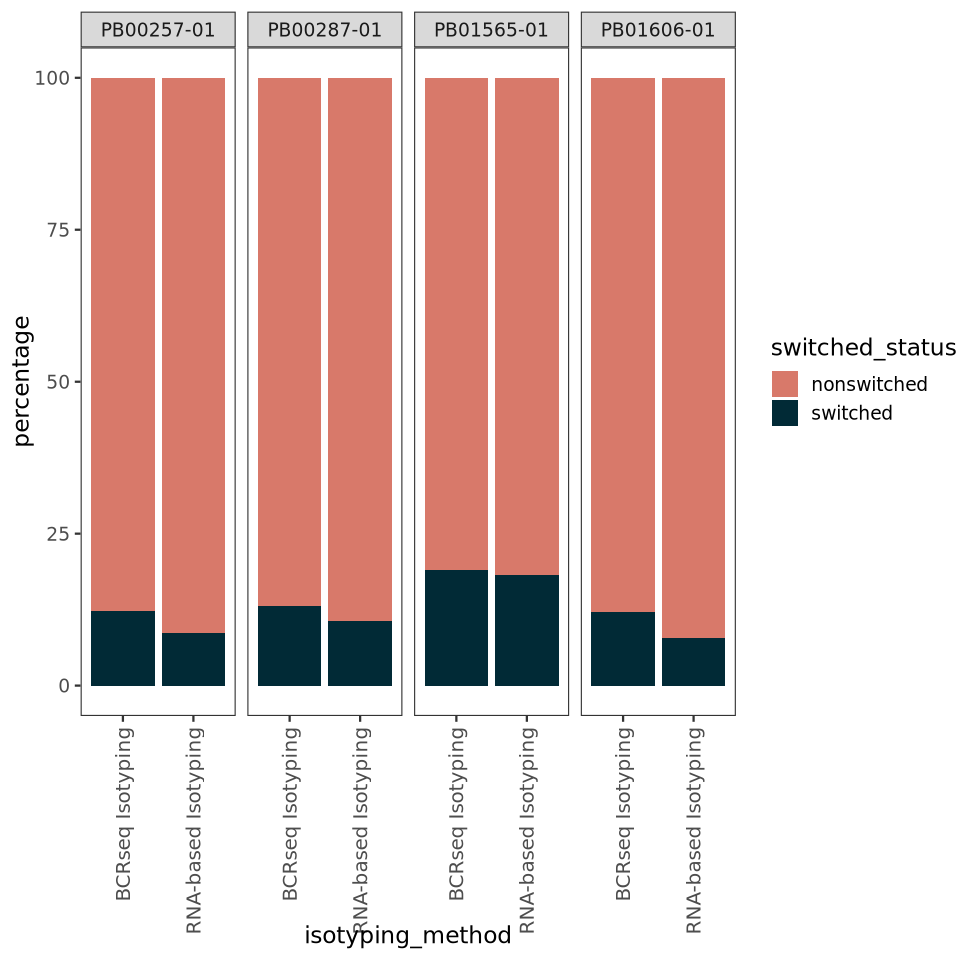

In [57]:
options(repr.plot.width = 8, repr.plot.height = 8)
ggplot(df, aes(x=isotyping_method, y=percentage, fill=switched_status)) + 
    geom_bar(stat = 'identity') + scale_fill_manual(values = c('#D8796A','#012A36')) +
    facet_wrap(~pbmc_sample_id_align, ncol=4) +
    theme_bw(base_size=14) + theme(axis.text.x = element_text(size=12, angle = 90,hjust=1,vjust=0.5),
                       panel.grid.major = element_blank(),
                       panel.grid.minor = element_blank())

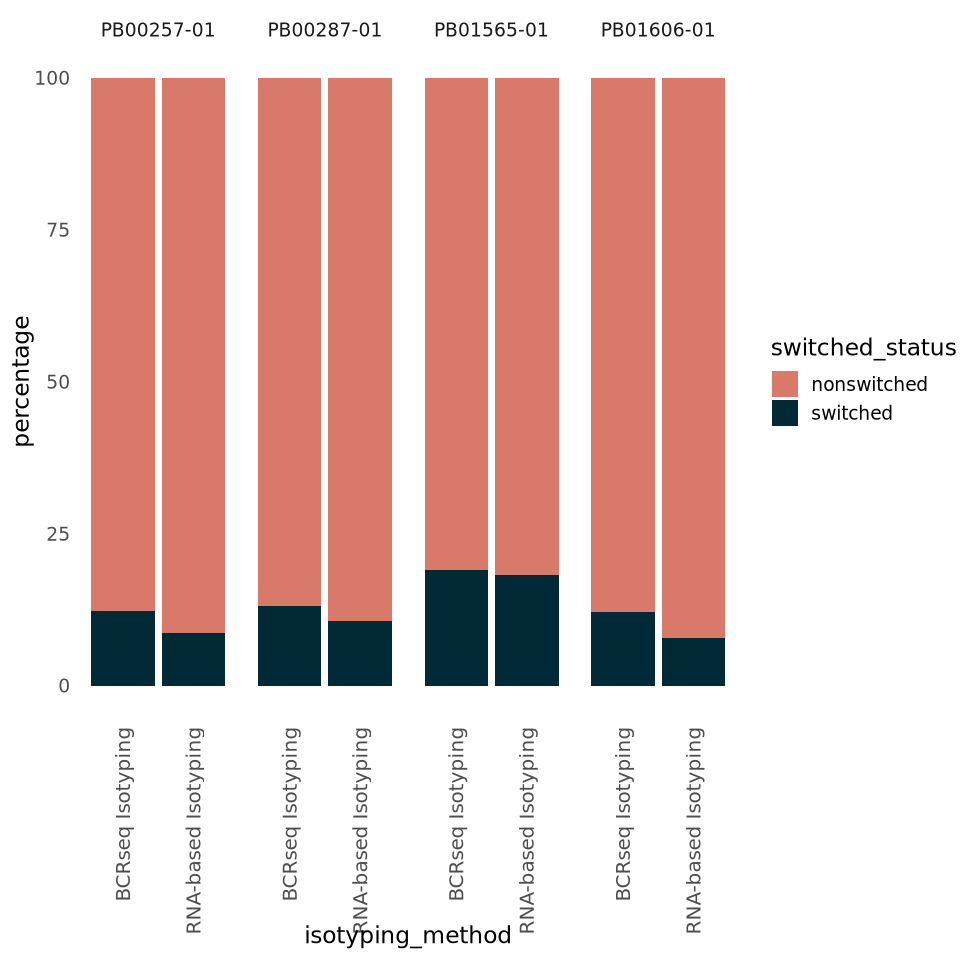

In [58]:
options(repr.plot.width = 8, repr.plot.height = 8)
ggplot(df, aes(x=isotyping_method, y=percentage, fill=switched_status)) + 
    geom_bar(stat = 'identity') + scale_fill_manual(values = c('#D8796A','#012A36')) +
    facet_wrap(~pbmc_sample_id_align, ncol=4) +
    theme_minimal(base_size=14) + theme(axis.text.x = element_text(size=12, angle = 90,hjust=1,vjust=0.5),
                       panel.grid.major = element_blank(),
                       panel.grid.minor = element_blank())

In [59]:
df2 <- merged_obj@meta.data %>% 
    dplyr::group_by(switched_status,tech,isotyping_method) %>%
    dplyr::summarise(count=n()) %>%
    dplyr::group_by(tech) %>%
    dplyr::mutate(percentage = (count / sum(count)) * 100)

`summarise()` has grouped output by 'switched_status', 'tech'. You can override
using the `.groups` argument.


In [60]:
df2

switched_status,tech,isotyping_method,count,percentage
<chr>,<chr>,<fct>,<int>,<dbl>
nonswitched,prime3,RNA-based Isotyping,5166,88.88507
nonswitched,prime5,BCRseq Isotyping,89812,86.12251
switched,prime3,RNA-based Isotyping,646,11.11493
switched,prime5,BCRseq Isotyping,14472,13.87749


## Plot

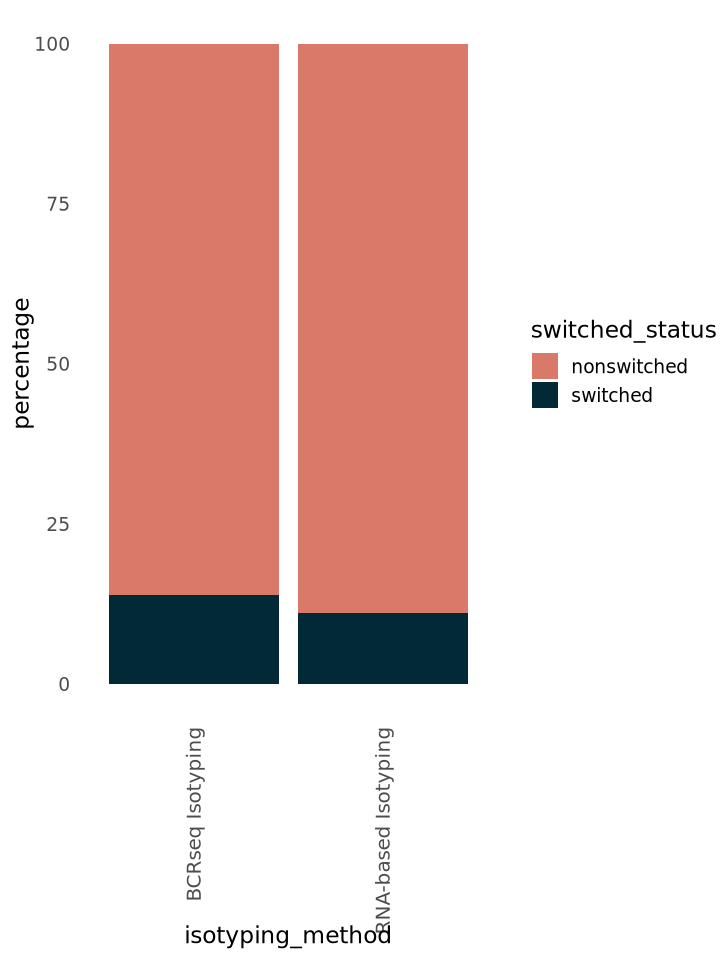

In [61]:
options(repr.plot.width = 6, repr.plot.height = 8)
p3 <- ggplot(df2, aes(x=isotyping_method, y=percentage, fill=switched_status)) + 
        geom_bar(stat = 'identity') + scale_fill_manual(values = c('#D8796A','#012A36')) +
        theme_minimal(base_size=14) + theme(axis.text.x = element_text(size=12, angle = 90,hjust=1,vjust=0.5),
                           panel.grid.major = element_blank(),
                           panel.grid.minor = element_blank())
p3

In [62]:
# Open a pdf file
pdf("plots/switched_percentage.pdf", width = 6, height = 8) 
# 2. Create a plot
p3
# Close the pdf file
dev.off() 

pdf 
  2

In [63]:
sessionInfo()

R version 4.4.1 (2024-06-14)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/minimal/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] DESeq2_1.46.0               SingleCellExperiment_1.28.0
 [3] SummarizedExperiment_1.36.0 Biobase_2.66.0             
 [5] GenomicRanges_1.58.0        GenomeInfoDb_1.42.0        
 [7] IRanges_2.40.0              S4Vectors_0.44.0           
 [9] BiocGenerics_0.52.0         MatrixGenerics_1.18.0      
[1